In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.shape

(53940, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
# price > 3000 ise true, değilse false olacak şekilde yeni bir target değişken oluşturalım.

df["price_category"] = (df["price"] > 3000).astype(int)
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_category
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,0
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,0
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,0
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,0
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64,0


In [9]:
df["price_category"].value_counts()

price_category
0    30336
1    23604
Name: count, dtype: int64

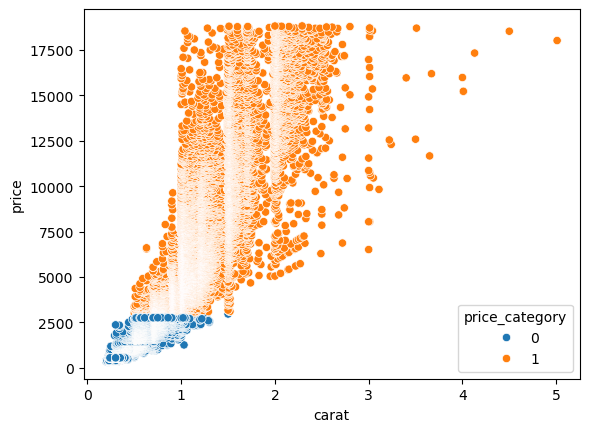

In [13]:
sns.scatterplot(data=df, x="carat", y="price", hue="price_category")
plt.show()

In [16]:
# dependent & independent features
X = df.drop(columns=["price_category", "price"], axis=1)
y = df["price_category"]

In [18]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [22]:
#!pip install catboost

In [23]:
from catboost import CatBoostClassifier

In [25]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="Accuracy",
    cat_features=["cut","color","clarity"],
    random_state=42,
    verbose=100,
    early_stopping_rounds=30
)

In [26]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.9537758	test: 0.9521691	best: 0.9521691 (0)	total: 240ms	remaining: 1m 59s
100:	learn: 0.9820583	test: 0.9840564	best: 0.9840564 (99)	total: 8.84s	remaining: 34.9s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.9840563589
bestIteration = 99

Shrink model to first 100 iterations.


In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:",accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9840563589173156

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      3065
           1       0.98      0.98      0.98      2329

    accuracy                           0.98      5394
   macro avg       0.98      0.98      0.98      5394
weighted avg       0.98      0.98      0.98      5394

Confusion Matrix:
 [[3027   38]
 [  48 2281]]


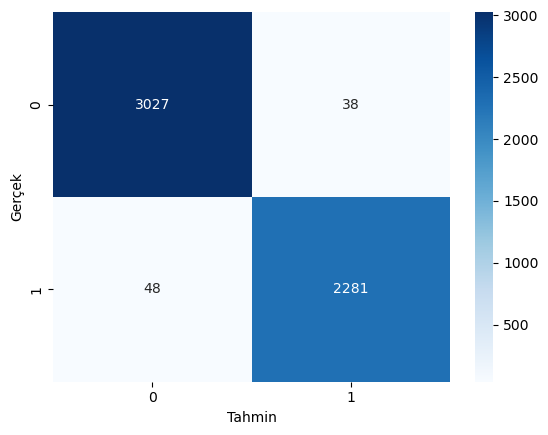

In [29]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()